DATASET SHAPE
(200, 5)

FIRST 5 ROWS
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

COLUMN NAMES
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending 

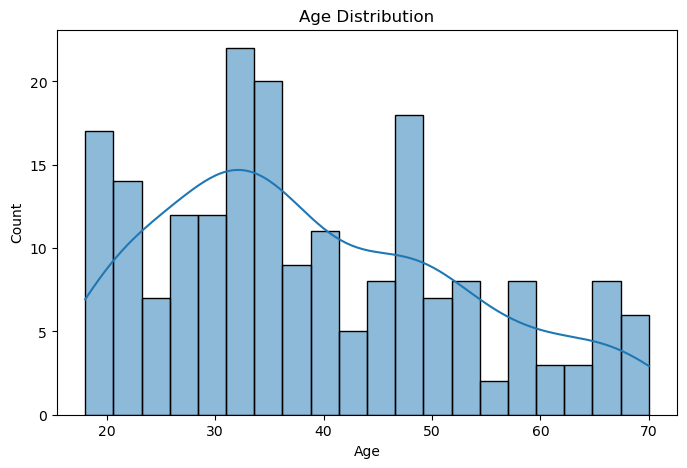

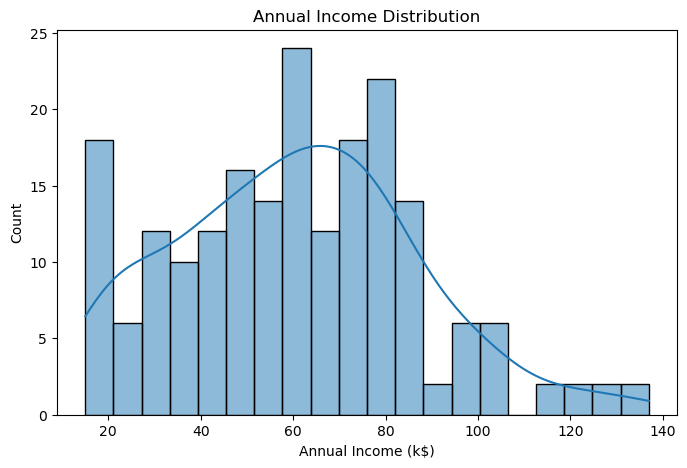

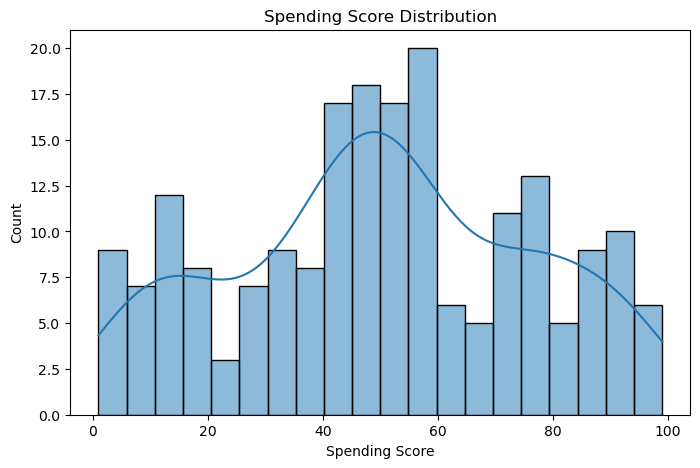

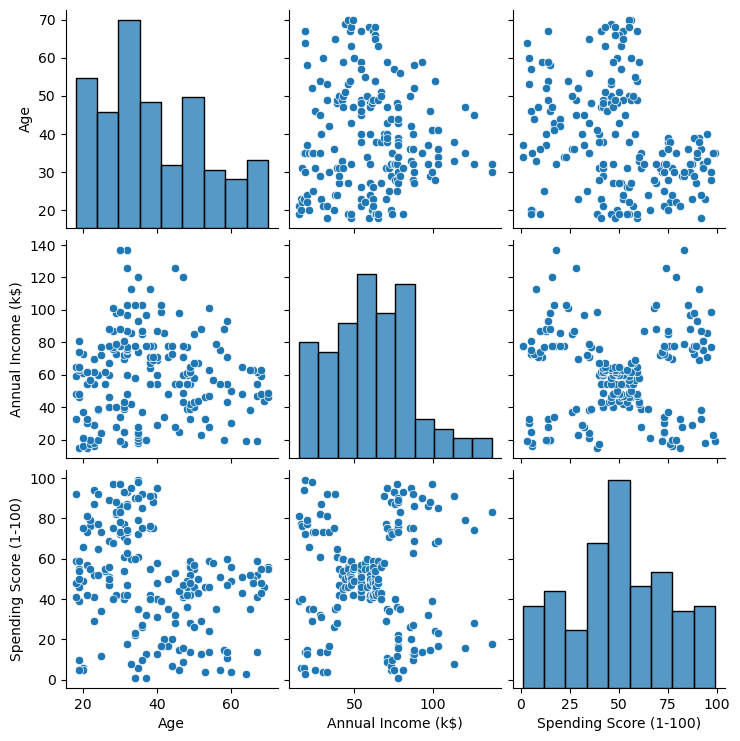

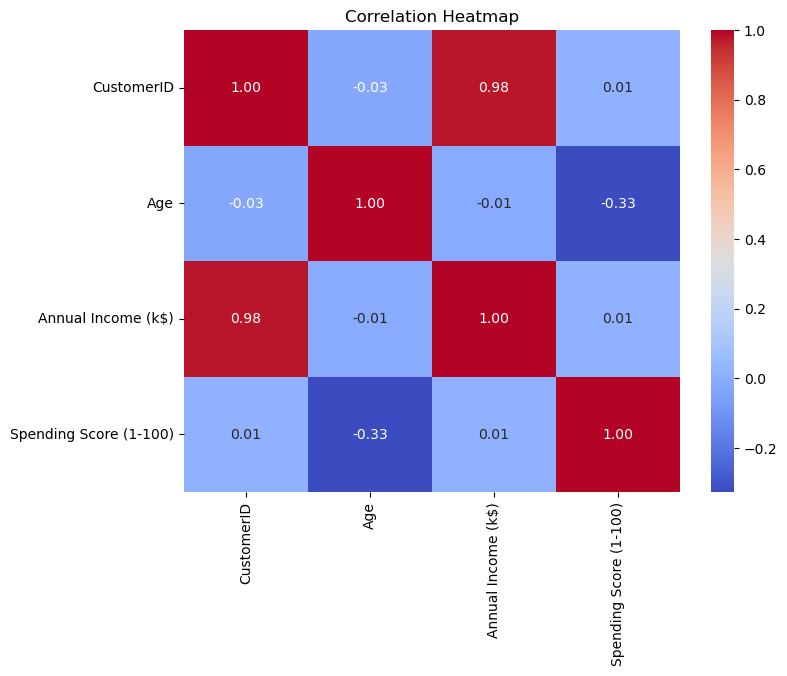


Features Used:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


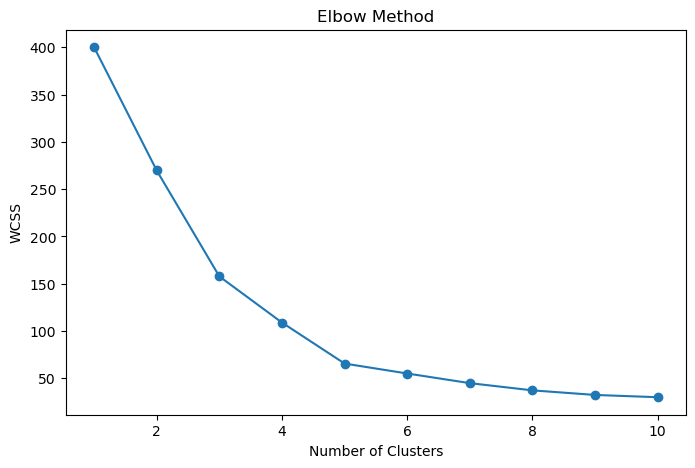


CLUSTER COUNTS
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


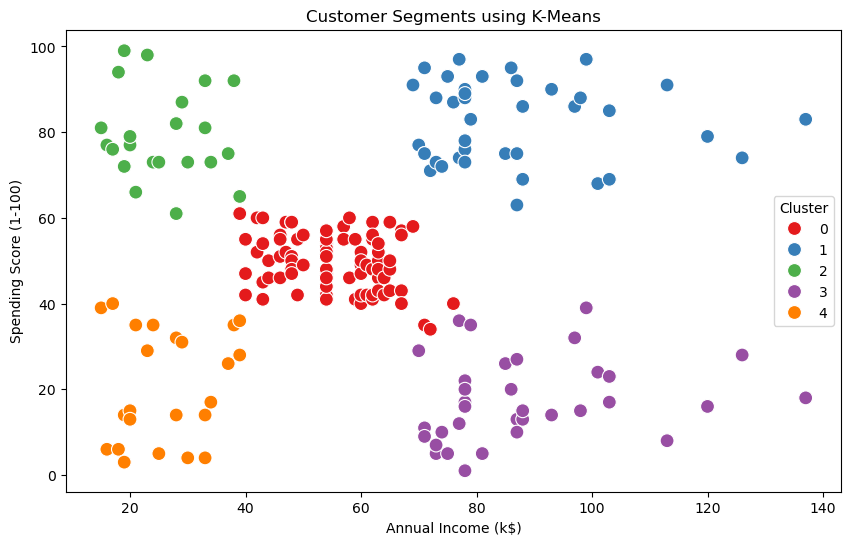

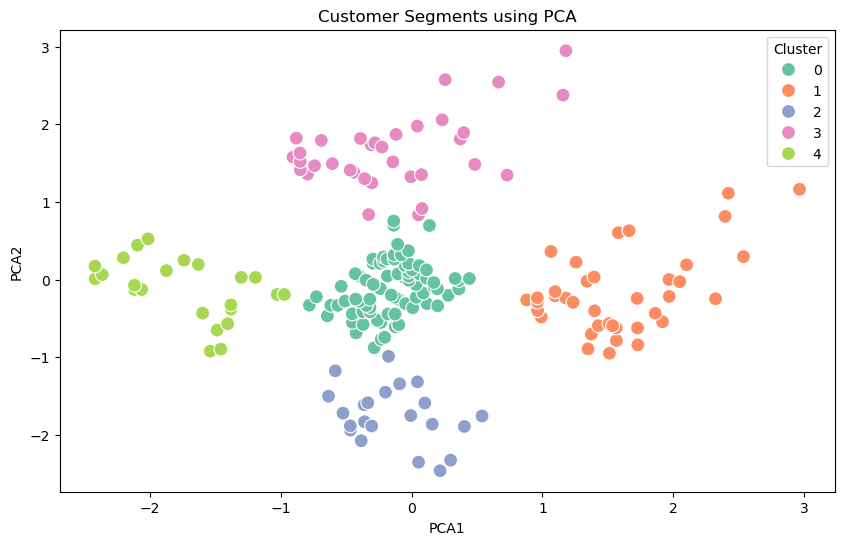


CLUSTER SUMMARY
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043

MARKETING STRATEGIES

Cluster 0
Segment: Low Income - Low Spending
Strategy:
- Introductory offers
- Awareness campaigns
- Budget product recommendations

Cluster 1
Segment: High Income - High Spending
Strategy:
- Premium memberships
- VIP rewards
- Exclusive product launches

Cluster 2
Segment: Low Income - High Spending
Strategy:
- Discount vouchers
- Cashback offers
- Loyalty points

Cluster 3
Segment: High Income - Low Spending
Strategy:
- Personalized promotions
- Luxury recommendations
- Re-engagement campaigns

Cluster 4
Segment

In [1]:
# TASK 2: CUSTOMER SEGMENTATION USING UNSUPERVISED LEARNING
# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# 2. LOAD DATASET
# -----------------------------
# Change the path according to your system
df = pd.read_csv(r"G:\Mall_Customers.csv")

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS:", df.duplicated().sum())

# -----------------------------
# 3. DATA CLEANING
# -----------------------------
df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print(df.shape)

# -----------------------------
# 4. EXPLORATORY DATA ANALYSIS
# -----------------------------

print("\nSUMMARY STATISTICS")
print(df.describe())

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

# Annual Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.show()

# Spending Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.show()

# Pairplot
sns.pairplot(df.drop('CustomerID', axis=1))
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 5. FEATURE SELECTION
# -----------------------------
# Using income and spending score for clustering

X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

print("\nFeatures Used:")
print(X.head())

# -----------------------------
# 6. FEATURE SCALING
# -----------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -----------------------------
# 7. ELBOW METHOD
# -----------------------------
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# -----------------------------
# 8. K-MEANS CLUSTERING
# -----------------------------
optimal_clusters = 5

kmeans = KMeans(
    n_clusters=optimal_clusters,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nCLUSTER COUNTS")
print(df['Cluster'].value_counts())

# -----------------------------
# 9. CLUSTER VISUALIZATION
# -----------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Customer Segments using K-Means")

plt.show()

# -----------------------------
# 10. PCA VISUALIZATION
# -----------------------------
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2',
    s=100
)

plt.title("Customer Segments using PCA")

plt.show()

# -----------------------------
# 11. CLUSTER ANALYSIS
# -----------------------------
cluster_summary = df.groupby('Cluster')[
    ['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

print("\nCLUSTER SUMMARY")
print(cluster_summary)

# -----------------------------
# 12. MARKETING STRATEGIES
# -----------------------------
print("\n" + "="*60)
print("MARKETING STRATEGIES")
print("="*60)

for cluster in cluster_summary.index:

    income = cluster_summary.loc[cluster,
                                 'Annual Income (k$)']

    spending = cluster_summary.loc[cluster,
                                   'Spending Score (1-100)']

    print(f"\nCluster {cluster}")

    if income >= 70 and spending >= 60:
        print("Segment: High Income - High Spending")
        print("Strategy:")
        print("- Premium memberships")
        print("- VIP rewards")
        print("- Exclusive product launches")

    elif income >= 70 and spending < 60:
        print("Segment: High Income - Low Spending")
        print("Strategy:")
        print("- Personalized promotions")
        print("- Luxury recommendations")
        print("- Re-engagement campaigns")

    elif income < 70 and spending >= 60:
        print("Segment: Low Income - High Spending")
        print("Strategy:")
        print("- Discount vouchers")
        print("- Cashback offers")
        print("- Loyalty points")

    else:
        print("Segment: Low Income - Low Spending")
        print("Strategy:")
        print("- Introductory offers")
        print("- Awareness campaigns")
        print("- Budget product recommendations")

# -----------------------------
# 13. FINAL CONCLUSION
# -----------------------------
print("\n" + "="*60)
print("FINAL CONCLUSION")
print("="*60)

print("""
K-Means clustering successfully segmented mall customers
based on Annual Income and Spending Score.

PCA reduced the data into two dimensions, making the
clusters easier to visualize.

These customer segments enable businesses to design
targeted marketing strategies, improve customer
engagement, and increase profitability through
data-driven decision making.
""")